# Previsão de Ações do Setor Elétrico

## 1. O Mercado de Energia Elétrica no Brasil

O setor elétrico brasileiro é dividido em três segmentos principais: **geração**, **transmissão** e **distribuição**. Cada segmento tem uma dinâmica econômica diferente, mas todos compartilham um elemento central: a regulação pela **ANEEL** (Agência Nacional de Energia Elétrica).

### Como funciona a regulação?

A ANEEL define as tarifas e receitas das empresas reguladas através de contratos de concessão. Isso significa que, ao contrário de empresas de outros setores, as receitas dessas companhias **não dependem diretamente do volume de energia consumida** no caso da transmissão, ou têm grande previsibilidade no caso da distribuição. As tarifas são corrigidas periodicamente por índices de inflação (IPCA ou IGP-M), criando um fluxo de caixa estável e previsível.


## 2. As Empresas da Carteira

A carteira foi construída com **quatro empresas do setor elétrico regulado**, cobrindo diferentes segmentos da cadeia de valor:

### TAEE11 — Taesa (Transmissão Paulista de Energia Elétrica)

A Taesa é uma das maiores empresas de **transmissão de energia elétrica** do Brasil. Seu modelo de negócio é simples e extremamente previsível: ela recebe uma **Receita Anual Permitida (RAP)** da ANEEL, independentemente do volume de energia que passa pelos seus fios. Isso significa que a Taesa não sofre com variações no consumo de energia — sua receita é contratual.

- **Segmento:** Transmissão pura  
- **Regulação:** RAP definida pela ANEEL, corrigida por IPCA/IGP-M  
- **Perfil:** Altíssimo dividend yield, baixa volatilidade, sensível à curva de juros  
- **Risco principal:** Revisões tarifárias periódicas da ANEEL e vencimento de concessões

### CPFE3 — CPFL Energia

A CPFL é uma das maiores empresas de **distribuição e geração** de energia do Brasil, atuando principalmente no interior de São Paulo e em outros estados. Ao contrário da Taesa, a CPFL tem exposição ao consumo de energia elétrica na distribuição, além de um portfólio de geração renovável (PCHs e eólicas).

- **Segmento:** Distribuição + Geração  
- **Regulação:** Tarifas de distribuição revisadas pela ANEEL a cada 4-5 anos  
- **Perfil:** Bom dividend yield, exposição ao crescimento econômico regional  
- **Risco principal:** Perdas na distribuição (furtos de energia), inadimplência de consumidores

### EGIE3 — Engie Brasil

A Engie Brasil é a maior **geradora privada de energia renovável** do país, com usinas hidrelétricas, eólicas e solares. Seu modelo se baseia em **PPAs** (Power Purchase Agreements) — contratos de longo prazo que garantem a venda de energia a preços pré-definidos. A Engie é controlada pelo grupo francês Engie S.A., o que traz uma governança corporativa diferenciada.

- **Segmento:** Geração renovável  
- **Regulação:** PPAs de longo prazo + mercado livre de energia  
- **Perfil:** Crescimento via expansão da capacidade instalada, exposição ao PLD (preço spot)  
- **Risco principal:** Hidrologia (seca reduz geração hidráulica), variação do PLD

### CMIG4 — Cemig (Companhia Energética de Minas Gerais)

A Cemig é a maior empresa de energia de Minas Gerais e uma das maiores do Brasil. É uma empresa **verticalizada** — atua em geração, transmissão e distribuição simultaneamente. Por ser uma estatal (controlada pelo governo de Minas Gerais), carrega um **risco político adicional**: decisões do governo estadual podem impactar a estratégia empresarial e a política de dividendos.

- **Segmento:** Integrada (geração + transmissão + distribuição)  
- **Regulação:** Múltiplos contratos com a ANEEL em diferentes segmentos  
- **Perfil:** Alta liquidez, dividendos variáveis, desconto de holding  
- **Risco principal:** Interferência política do governo de MG, complexidade operacional

---

## 3. Por que essa carteira faz sentido?

As quatro empresas compartilham o mesmo **marco regulatório** (ANEEL) e têm receitas corrigidas por inflação, criando uma **correlação estrutural** entre elas. Quando o mercado reprecia o risco regulatório brasileiro, ou quando a curva de juros (especialmente a NTN-B) se move, todas as quatro reagem na mesma direção.

Ao mesmo tempo, cada empresa tem um perfil de risco diferente — a Taesa é mais defensiva, a Engie tem exposição ao crescimento renovável, a CPFL é sensível ao ciclo econômico regional e a Cemig carrega risco político. Essa diversificação **dentro do setor** é o que torna a carteira interessante para um modelo de LSTM: há correlação suficiente para o modelo aprender padrões comuns, mas variância suficiente para que as previsões sejam individualmente informativas.

---

## 4. Estratégia de Treino e Exclusão da Pandemia

### Por que excluímos 2019–2021?

O período da pandemia de COVID-19 (2019–2021) representa um **structural break** — uma ruptura estrutural na série temporal. Durante esse período:

- O consumo de energia elétrica caiu abruptamente com o fechamento de indústrias e comércio
- A Selic atingiu a mínima histórica de 2% a.a. (um regime completamente atípico)
- Os preços das ações reagiram a fatores não-econômicos (lockdowns, incerteza sanitária, estímulos fiscais)
- O PLD (preço spot de energia) ficou represado artificialmente

Treinar o modelo com esses dados contaminaria os pesos da rede com padrões que **não se repetem** em condições normais de mercado.

### Dois períodos de treino

Utilizamos dois períodos de treino com lógicas complementares:

- **2014–2018:** Captura os padrões estruturais de longo prazo do setor — ciclos de juros, revisões tarifárias da ANEEL, sazonalidade regulatória. Com 1.243 dias úteis, o modelo aprende os fundamentos do setor.
- **2022:** Expõe o modelo ao regime atual — juros altos pós-pandemia, Selic entre 10–13%, volatilidade típica do mercado recente. Com 250 dias úteis, o modelo aprende o ambiente em que vai ser testado.

Esse design evita o regime shift: o modelo não aprende só o passado distante, mas também o presente.

---

## 5. Instalação e Imports

In [1]:
!pip install torch pandas numpy scikit-learn matplotlib requests --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from datetime import datetime
from copy import deepcopy

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

Dispositivo: cpu


## 6. Configurações Gerais

In [3]:
# ── Ativos
TICKERS = ['TAEE11.SA', 'CPFE3.SA', 'EGIE3.SA', 'CMIG4.SA']
NOMES   = {'TAEE11.SA': 'Taesa', 'CPFE3.SA': 'CPFL Energia',
           'EGIE3.SA': 'Engie Brasil', 'CMIG4.SA': 'Cemig'}

# ── Períodos (pandemia 2019-2021 excluída — structural break)
PERIODOS_TREINO = [('2014-01-01', '2018-12-31'), ('2022-01-01', '2022-12-31')]
PERIODO_TESTE   = ('2023-01-01', '2025-12-31')

# ── Hiperparâmetros
SEQ_LEN    = 30    # janela de entrada: 30 dias úteis (~1,5 mês)
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-3

# ── Arquitetura
HIDDEN_LSTM = 64
HIDDEN_GRU  = 32

## 7. Coleta de Dados

Utilizamos a **API v8 do Yahoo Finance** via `requests` puro, sem depender do `yfinance`. Essa abordagem é mais robusta em ambientes como Google Colab e Kaggle, onde o `yfinance` pode falhar por bloqueios de DNS.

Os dados coletados são os **preços de fechamento ajustado** — já corrigidos por dividendos e desdobramentos, o que garante comparabilidade ao longo do tempo.

In [4]:
def baixar_ticker(ticker, inicio, fim):
    """Baixa fechamento ajustado via API v8 do Yahoo Finance."""
    ts1 = int(datetime.strptime(inicio, '%Y-%m-%d').timestamp())
    ts2 = int(datetime.strptime(fim,    '%Y-%m-%d').timestamp())
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0',
        'Accept': 'application/json'
    }
    for t in [ticker, ticker.replace('.SA', '.SAO')]:
        url = (f'https://query2.finance.yahoo.com/v8/finance/chart/{t}'
               f'?period1={ts1}&period2={ts2}&interval=1d&events=adjclose')
        try:
            r = requests.get(url, headers=headers, timeout=15)
            r.raise_for_status()
            chart = r.json()['chart']['result'][0]
            try:
                closes = chart['events']['adjclose']['adjclose']
            except (KeyError, TypeError):
                closes = chart['indicators']['quote'][0]['close']
            datas = pd.to_datetime(chart['timestamp'], unit='s').normalize()
            s = pd.Series(closes, index=datas, name=ticker, dtype=float).dropna()
            if not s.empty:
                return s
        except Exception:
            continue
    return None


def baixar_dados(tickers, inicio, fim):
    """Baixa todos os tickers e retorna DataFrame alinhado."""
    series = {}
    for t in tickers:
        s = baixar_ticker(t, inicio, fim)
        if s is not None:
            series[t] = s
            print(f'  ✓ {t:12s}  {len(s)} dias')
        else:
            print(f'  ✗ {t:12s}  falhou')
    df = pd.DataFrame(series)[tickers]
    return df.ffill().dropna()

In [5]:
# Burn-in: baixamos 3 meses antes de cada período para que os indicadores
# rolling (SMA 60d, vol 20d) sejam calculados corretamente desde o 1º dia de treino.

print('Baixando 2014-2018...')
df_p1 = baixar_dados(TICKERS, '2013-09-01', '2018-12-31')

print('\nBaixando 2022...')
df_p2 = baixar_dados(TICKERS, '2021-09-01', '2022-12-31')

print('\nBaixando teste 2023-2025...')
df_te = baixar_dados(TICKERS, '2022-07-01', '2025-12-31')

Baixando 2014-2018...
  ✓ TAEE11.SA     1325 dias
  ✓ CPFE3.SA      1325 dias
  ✓ EGIE3.SA      1325 dias
  ✓ CMIG4.SA      1325 dias

Baixando 2022...
  ✓ TAEE11.SA     332 dias
  ✓ CPFE3.SA      332 dias
  ✓ EGIE3.SA      332 dias
  ✓ CMIG4.SA      332 dias

Baixando teste 2023-2025...
  ✓ TAEE11.SA     875 dias
  ✓ CPFE3.SA      875 dias
  ✓ EGIE3.SA      875 dias
  ✓ CMIG4.SA      875 dias


## 8. Indicadores Técnicos (Features)

Para cada ativo calculamos **6 indicadores técnicos** que servirão como features de entrada da rede:

| Feature | Fórmula | Interpretação |
|---|---|---|
| `ret_log` | ln(P_t / P_{t-1}) | **Target** — retorno logarítmico diário. Estacionário e comparável entre períodos |
| `vol20` | std(ret_log, 20d) | Volatilidade realizada — captura momentos de estresse do mercado |
| `SMA_14` | média(P, 14d) / P | Tendência de curto prazo normalizada pelo preço atual |
| `SMA_60` | média(P, 60d) / P | Tendência de médio prazo — captura ciclos tarifários trimestrais |
| `EMA_14` | ewm(P, 14d) / P | Média exponencial — mais sensível a movimentos recentes |
| `RSI_14` | 100 - 100/(1+RS) | Momentum — identifica sobrecompra (>70) e sobrevenda (<30) |



In [6]:
def add_indicators(df, window=14):
    """
    Calcula 6 indicadores técnicos para todos os ativos do DataFrame.
    Retorna DataFrame com window=14 por padrão (SMA_14, EMA_14, RSI_14).
    """
    feat = pd.DataFrame(index=df.index)
    for col in df.columns:
        p    = df[col]
        nome = col.replace('.SA', '')

        # Retorno logarítmico (target do modelo)
        feat[f'{nome}_ret_log'] = np.log(p / p.shift(1))

        # Volatilidade realizada 20 dias
        feat[f'{nome}_vol20'] = feat[f'{nome}_ret_log'].rolling(20).std()

        # SMA normalizada pelo preço (evita não-estacionariedade)
        feat[f'{nome}_SMA_{window}'] = p.rolling(window).mean() / p
        feat[f'{nome}_SMA_60']       = p.rolling(60).mean() / p

        # EMA (ponderação exponencial — reage mais rápido a mudanças)
        feat[f'{nome}_EMA_{window}'] = p.ewm(span=window, adjust=False).mean() / p

        # RSI — momentum oscilador entre 0 e 100
        delta = p.diff()
        ganho = delta.clip(lower=0).rolling(window).mean()
        perda = (-delta.clip(upper=0)).rolling(window).mean()
        feat[f'{nome}_RSI_{window}'] = 100 - (100 / (1 + ganho / (perda + 1e-9)))

    return feat.dropna()

In [7]:
# Calcula features e aplica corte de burn-in
feat_p1 = add_indicators(df_p1)
feat_p1 = feat_p1[feat_p1.index >= PERIODOS_TREINO[0][0]]

feat_p2 = add_indicators(df_p2)
feat_p2 = feat_p2[feat_p2.index >= PERIODOS_TREINO[1][0]]

# Concatena os dois períodos de treino sem sobreposição
feat_treino = pd.concat([feat_p1, feat_p2]).sort_index()
feat_treino = feat_treino[~feat_treino.index.duplicated(keep='first')]

# Teste: burn-in de 2022-07 cobre o rolling do início de 2023
feat_te_raw = add_indicators(df_te)
feat_teste  = feat_te_raw[feat_te_raw.index >= PERIODO_TESTE[0]]

print(f'Treino: {len(feat_treino)} dias  ({len(feat_p1)} de 2014–18 + {len(feat_p2)} de 2022)')
print(f'Teste:  {len(feat_teste)} dias')
print(f'Features: {len(feat_treino.columns)} ({len(TICKERS)} ativos × 6 indicadores)')
feat_treino.head(3)

Treino: 1493 dias  (1243 de 2014–18 + 250 de 2022)
Teste:  749 dias
Features: 24 (4 ativos × 6 indicadores)


,TAEE11_ret_log,TAEE11_vol20,TAEE11_SMA_14,TAEE11_SMA_60,TAEE11_EMA_14,TAEE11_RSI_14,CPFE3_ret_log,CPFE3_vol20,CPFE3_SMA_14,CPFE3_SMA_60,...,EGIE3_SMA_14,EGIE3_SMA_60,EGIE3_EMA_14,EGIE3_RSI_14,CMIG4_ret_log,CMIG4_vol20,CMIG4_SMA_14,CMIG4_SMA_60,CMIG4_EMA_14,CMIG4_RSI_14
2014-01-02,-0.002751,0.015815,1.033963,1.154849,1.037036,11.699166,-0.031394,0.015745,1.016525,1.036261,...,0.992216,1.025155,0.996628,41.296930,-0.017279,0.012574,1.010612,1.065704,1.017869,34.977676
2014-01-03,0.023415,0.017288,1.003229,1.125493,1.011298,24.495680,0.004315,0.015007,1.012071,1.031109,...,0.986546,1.019280,0.991906,52.573515,0.030750,0.014786,0.979044,1.032822,0.988773,46.442549
2014-01-06,-0.009735,0.017246,1.005551,1.133560,1.018365,23.415981,-0.006479,0.015055,1.018921,1.037098,...,1.004995,1.038864,1.009682,44.409937,0.005618,0.014340,0.974531,1.025986,0.985469,53.930402


## 9. Normalização dos Dados



In [8]:
# Scaler separado por período — fit APENAS no treino
scaler_tr = MinMaxScaler()
scaler_te = MinMaxScaler()

scaled_treino = scaler_tr.fit_transform(feat_treino.values)
scaled_teste  = scaler_te.fit_transform(feat_teste.values)

print(f'Shape treino normalizado: {scaled_treino.shape}')
print(f'Shape teste normalizado:  {scaled_teste.shape}')

Shape treino normalizado: (1493, 24)
Shape teste normalizado:  (749, 24)


## 10. Criando Sequências Multivariadas



In [9]:
# Índices das colunas de retorno log — target do modelo
colunas     = feat_treino.columns.tolist()
idx_targets = [i for i, c in enumerate(colunas) if c.endswith('_ret_log')]
nomes_ativos = [colunas[i].replace('_ret_log', '') for i in idx_targets]

print(f'Targets: {[colunas[i] for i in idx_targets]}')


def create_multivariate_sequences(data, seq_len, idx_targets):
    """
    Cria sequências para entrada na LSTM.
    X[i]: janela de seq_len dias com todas as features → (seq_len, n_features)
    y[i]: retornos log dos 4 ativos no próximo dia    → (n_targets,)
    """
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i])       # entrada: janela passada
        y.append(data[i, idx_targets])       # target: próximo dia
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

Targets: ['TAEE11_ret_log', 'CPFE3_ret_log', 'EGIE3_ret_log', 'CMIG4_ret_log']


In [10]:
X, y = create_multivariate_sequences(scaled_treino, SEQ_LEN, idx_targets)
X_te, y_te = create_multivariate_sequences(scaled_teste, SEQ_LEN, idx_targets)

# Divisão treino / validação: 80% / 20%
# Sem embaralhar — respeita a ordem temporal das séries
split   = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}  y_val:   {y_val.shape}')
print(f'X_test:  {X_te.shape}  y_test:  {y_te.shape}')

X_train: (1170, 30, 24)  y_train: (1170, 4)
X_val:   (293, 30, 24)  y_val:   (293, 4)
X_test:  (719, 30, 24)  y_test:  (719, 4)


## 11. Dataset e DataLoader



In [11]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = TimeSeriesDataset(X_train, y_train)
val_ds   = TimeSeriesDataset(X_val,   y_val)
test_ds  = TimeSeriesDataset(X_te,    y_te)

# shuffle=True no treino melhora a generalização
# shuffle=False na validação e teste — ordem temporal importa na avaliação
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

## 12. Arquitetura do Modelo — LSTM + GRU



In [12]:
class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size, hidden_lstm=64, hidden_gru=32, n_targets=4):
        super().__init__()

        # LSTM: aprende dependências de longo prazo (ciclos regulatórios)
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_lstm,
                            num_layers=2, batch_first=True, dropout=0.2)

        # GRU: refina as representações com menos parâmetros
        self.gru = nn.GRU(input_size=hidden_lstm, hidden_size=hidden_gru,
                          batch_first=True)

        self.dropout = nn.Dropout(0.2)

        # Camada densa: projeta o hidden final nos n_targets retornos
        self.fc = nn.Linear(hidden_gru, n_targets)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out_lstm, _ = self.lstm(x)             # (batch, seq_len, hidden_lstm)
        out_gru,  _ = self.gru(out_lstm)        # (batch, seq_len, hidden_gru)
        out = self.dropout(out_gru[:, -1, :])   # último passo temporal
        return self.fc(out)                     # (batch, n_targets)


input_size = X_train.shape[2]
model = LSTM_GRU_Model(input_size=input_size,
                        hidden_lstm=HIDDEN_LSTM,
                        hidden_gru=HIDDEN_GRU,
                        n_targets=len(idx_targets)).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {total_params:,}')
print(model)

Parâmetros treináveis: 65,860
LSTM_GRU_Model(
  (lstm): LSTM(24, 64, num_layers=2, batch_first=True, dropout=0.2)
  (gru): GRU(64, 32, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=32, out_features=4, bias=True)
)


## 13. Treinamento

O loop de treino utiliza três técnicas para garantir qualidade:

- **Early Stopping** (paciência = 10 épocas): interrompe o treino quando a loss de validação para de melhorar, evitando overfitting
- **Gradient Clipping** (`max_norm=1.0`): limita a magnitude dos gradientes, prevenindo explosão de gradiente — comum em RNNs com séries financeiras voláteis
- **ReduceLROnPlateau**: reduz a taxa de aprendizado pela metade quando a validação estagna, permitindo ajustes mais finos

 Época   Treino MSE    Val MSE         LR
──────────────────────────────────────────
     5      0.01306    0.00538    1.0e-03
    10      0.01192    0.00538    1.0e-03
    15      0.01109    0.00558    5.0e-04
    20      0.01080    0.00534    5.0e-04
    25      0.01040    0.00544    2.5e-04

  Early stopping na época 28 | melhor val MSE: 0.00531


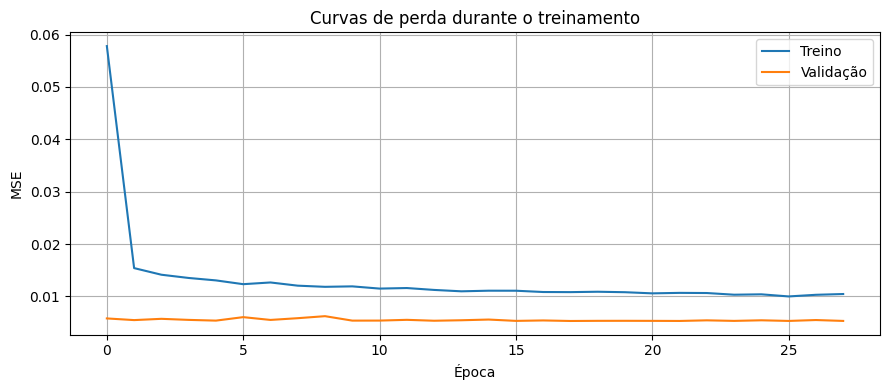

In [13]:
best_val_loss    = float('inf')
best_model_state = None
train_losses, val_losses = [], []
paciencia, contador = 10, 0

print(f"{'Época':>6} {'Treino MSE':>12} {'Val MSE':>10} {'LR':>10}")
print('─' * 42)

for epoch in range(1, EPOCHS + 1):
    # ── Treino
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # ── Validação
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_batch_losses.append(criterion(model(xb), yb).item())
    val_loss = np.mean(val_batch_losses)

    lr_atual = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 5 == 0:
        print(f'{epoch:>6} {train_loss:>12.5f} {val_loss:>10.5f} {lr_atual:>10.1e}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = deepcopy(model.state_dict())
        contador = 0
    else:
        contador += 1
        if contador >= paciencia:
            print(f'\n  Early stopping na época {epoch} | melhor val MSE: {best_val_loss:.5f}')
            break

model.load_state_dict(best_model_state)

# Curvas de perda
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Treino')
plt.plot(val_losses,   label='Validação')
plt.title('Curvas de perda durante o treinamento')
plt.xlabel('Época'); plt.ylabel('MSE')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

## 14. Avaliação e Interpretação dos Resultados

### Métricas utilizadas

- **MAE (R\$):** erro absoluto médio em reais. Interpretação direta: em média, o modelo erra X reais por dia.
- **RMSE (R\$):** penaliza erros grandes. Se for muito maior que o MAE, o modelo erra muito em dias de alta volatilidade.
- **Acurácia Direcional (DA):** percentual de dias em que o modelo acertou a **direção** do movimento (subiu ou caiu). Economicamente mais relevante que o MAE — um modelo que acerta a direção, mesmo errando a magnitude, já tem valor para estratégias de trading. Referência: modelo aleatório acerta 50%.

In [14]:
# Coleta previsões no conjunto de teste
model.eval()
preds_list, reais_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds_list.append(model(xb.to(DEVICE)).cpu().numpy())
        reais_list.append(yb.numpy())

preds_norm = np.concatenate(preds_list)   # (N, 4) retornos normalizados
reais_norm = np.concatenate(reais_list)


def desnorm(arr_norm, scaler, idx_targets):
    """Inverte MinMaxScaler apenas nas colunas de retorno log."""
    N, T = arr_norm.shape
    buf  = np.zeros((N, scaler.n_features_in_))
    for j, feat_idx in enumerate(idx_targets):
        buf[:, feat_idx] = arr_norm[:, j]
    dn = scaler.inverse_transform(buf)
    return dn[:, idx_targets]


preds_ret = desnorm(preds_norm, scaler_te, idx_targets)
reais_ret = desnorm(reais_norm, scaler_te, idx_targets)

# Reconstrói preços: P[t+1] = P[t] * exp(ret)
precos_te  = df_te[TICKERS]
precos_te  = precos_te[precos_te.index >= PERIODO_TESTE[0]].values
ancora     = precos_te[SEQ_LEN:SEQ_LEN + len(preds_ret)]
preds_preco = ancora * np.exp(preds_ret)
reais_preco = ancora * np.exp(reais_ret)

# Métricas
print('\n=== Métricas — conjunto de teste (2023–2025) ===')
print(f"  {'Ativo':<14} {'MAE (R$)':>10} {'RMSE (R$)':>10} {'Dir. Acc':>10}")
print('  ' + '─' * 48)
for i, nome in enumerate(nomes_ativos):
    p    = preds_preco[:, i]
    r    = reais_preco[:, i]
    mae  = mean_absolute_error(r, p)
    rmse = np.sqrt(mean_squared_error(r, p))
    da   = np.mean(np.sign(preds_ret[:, i]) == np.sign(reais_ret[:, i])) * 100
    print(f'  {nome:<14} {mae:>10.4f} {rmse:>10.4f} {da:>9.1f}%')


=== Métricas — conjunto de teste (2023–2025) ===
  Ativo            MAE (R$)  RMSE (R$)   Dir. Acc
  ────────────────────────────────────────────────
  TAEE11             0.4090     0.5026      48.8%
  CPFE3              0.7506     0.8539      54.7%
  EGIE3              0.2742     0.3705      52.6%
  CMIG4              0.1212     0.1639      51.9%


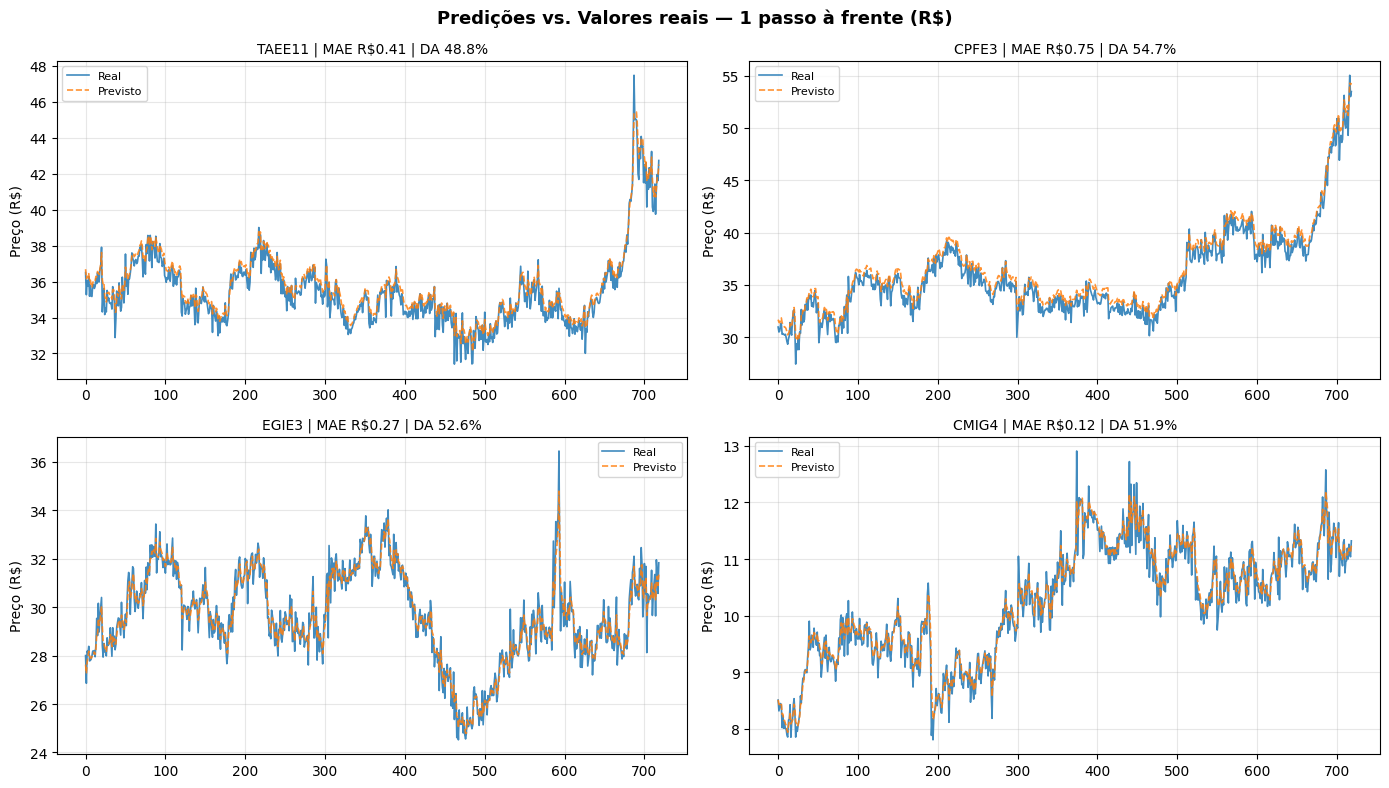

In [15]:
# Dashboard: predições vs reais por ativo
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Predições vs. Valores reais — 1 passo à frente (R$)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, (nome, ax) in enumerate(zip(nomes_ativos, axes)):
    r   = reais_preco[:, i]
    p   = preds_preco[:, i]
    mae = mean_absolute_error(r, p)
    da  = np.mean(np.sign(preds_ret[:, i]) == np.sign(reais_ret[:, i])) * 100
    ax.plot(r, label='Real',     linewidth=1.2, alpha=0.85)
    ax.plot(p, label='Previsto', linewidth=1.2, alpha=0.85, linestyle='--')
    ax.set_title(f'{nome} | MAE R${mae:.2f} | DA {da:.1f}%', fontsize=10)
    ax.set_ylabel('Preço (R$)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predicoes_carteira.png', dpi=150, bbox_inches='tight')
plt.show()